In [1]:
# Cell 1: Environment Setup and Dataset Extraction
%pip install ultralytics gradio torchvision torch pyyaml pillow opencv-python-headless matplotlib

import os
import zipfile

project_base = "."
zip_path = os.path.join(project_base, "dataset/Indonesian_Batik Motifs_(Corak_App).zip")
extract_path = os.path.join(project_base, "dataset/extracted_batik")

os.makedirs(extract_path, exist_ok=True)

if os.path.exists(extract_path) and len(os.listdir(extract_path)) > 0:
    print(f"Dataset already extracted at: {extract_path}. Skipping extraction.")
elif os.path.exists(zip_path):
    print(f"Extracting dataset from: {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction completed successfully!")
else:
    print(f"File not found: {zip_path}")

Note: you may need to restart the kernel to use updated packages.
Dataset already extracted at: ./dataset/extracted_batik. Skipping extraction.


In [2]:
# Cell 2: Automated Structure Organization and data.yaml Generation
import os
import glob
import shutil
import yaml

project_base = "."
extract_path = os.path.join(project_base, "dataset/extracted_batik")
target_base_dir = os.path.join(project_base, "dataset/split_textiles")

# Clear legacy directories to avoid data contamination from previous runs
if os.path.exists(target_base_dir):
    shutil.rmtree(target_base_dir)

sub_dirs = ['images/train', 'images/val', 'labels/train', 'labels/val']
for sub_dir in sub_dirs:
    os.makedirs(os.path.join(target_base_dir, sub_dir), exist_ok=True)

train_src = None
val_src = None

# Case-insensitive deep tree search for TRAIN and TEST folders
for root, dirs, _ in os.walk(extract_path):
    for d in dirs:
        if d.upper() == "TRAIN":
            train_src = os.path.join(root, d)
        elif d.upper() in ["TEST", "VAL"]:
            val_src = os.path.join(root, d)

if not train_src or not os.path.exists(train_src):
    raise FileNotFoundError(
        f"Target directory 'TRAIN' could not be resolved under {extract_path}. "
        "Verify that the archive extraction process completed successfully without corruption."
    )

classes = sorted([d for d in os.listdir(train_src) if os.path.isdir(os.path.join(train_src, d))])
class_to_idx = {name: idx for idx, name in enumerate(classes)}

stages_mapping = {'train': train_src, 'val': val_src}
image_extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')

for stage_target, stage_dir in stages_mapping.items():
    if not stage_dir or not os.path.exists(stage_dir):
        print(f"Warning: Source folder for stage '{stage_target}' is invalid. Skipping stage sequence.")
        continue
        
    for class_name in classes:
        class_idx = class_to_idx[class_name]
        class_path = os.path.join(stage_dir, class_name)
        
        if not os.path.exists(class_path):
            continue
            
        img_list = []
        for ext in image_extensions:
            img_list.extend(glob.glob(os.path.join(class_path, ext)))
            
        for img in img_list:
            orig_name = os.path.basename(img)
            # Prefix the unique class name to prevent overlapping namespace collisions (overwrite)
            clean_class_name = class_name.replace(" ", "_")
            unique_img_name = f"{clean_class_name}_{orig_name}"
            txt_name = os.path.splitext(unique_img_name)[0] + '.txt'
            
            shutil.copy(img, os.path.join(target_base_dir, f'images/{stage_target}', unique_img_name))
            with open(os.path.join(target_base_dir, f'labels/{stage_target}', txt_name), 'w') as f:
                f.write(f"{class_idx} 0.5 0.5 1.0 1.0\n")

yaml_path = os.path.join(project_base, "dataset/data.yaml")
yaml_data = {
    'path': os.path.abspath(target_base_dir),
    'train': 'images/train',
    'val': 'images/val',
    'names': {idx: name for idx, name in enumerate(classes)}
}

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)
    
print(f"Dataset organization completed successfully. Total classes identified: {len(classes)}")
print(f"Data configuration profile generated at: {yaml_path}")

Dataset organization completed successfully. Total classes identified: 10
Data configuration profile generated at: ./dataset/data.yaml


In [3]:
# Cell 3: Sequential Training and Loss Chart Generation
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

project_base = "."

class TextileDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.img_paths = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
            self.img_paths.extend(glob.glob(os.path.join(img_dir, ext)))

        self.labels = []
        for img_path in self.img_paths:
            label_path = img_path.replace('images', 'labels')
            label_path = os.path.splitext(label_path)[0] + '.txt'
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    first_line = f.readline().strip()
                    if first_line:
                        class_id = int(first_line.split()[0])
                        self.labels.append(class_id)
                    else:
                        self.labels.append(0)
            else:
                self.labels.append(0)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dir = os.path.join(project_base, "dataset/split_textiles/images/train")
val_dir = os.path.join(project_base, "dataset/split_textiles/images/val")

train_dataset = TextileDataset(train_dir, transform=data_transforms)
val_dataset = TextileDataset(val_dir, transform=data_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

all_labels = train_dataset.labels + val_dataset.labels
num_classes = len(set(all_labels)) if len(all_labels) > 0 else 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_folder = os.path.join(project_base, "models")
os.makedirs(model_folder, exist_ok=True)

models_to_train = {
    "resnet50": models.resnet50(weights=models.ResNet50_Weights.DEFAULT),
    "efficientnet": models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
}

models_to_train["resnet50"].fc = nn.Linear(models_to_train["resnet50"].fc.in_features, num_classes)
models_to_train["efficientnet"].classifier[1] = nn.Linear(models_to_train["efficientnet"].classifier[1].in_features, num_classes)

for name, model in models_to_train.items():
    print(f"\n--- Starting Training Loop for: {name.upper()} ---")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    num_epochs = 10
    loss_history = []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            
        epoch_loss = running_loss / len(train_dataset) if len(train_dataset) > 0 else 0
        loss_history.append(epoch_loss)
        print(f"[{name.upper()}] Epoch {epoch + 1}/{num_epochs} - Loss: {epoch_loss:.4f}")
        
    save_path = os.path.join(model_folder, f"{name}_textiles.pth")
    torch.save(model.state_dict(), save_path)
    print(f"Successfully saved {name.upper()} weights at: {save_path}")

    # Generate and save the loss curve chart for this model configuration
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_epochs + 1), loss_history, marker='o', color='g' if name == "efficientnet" else 'r', label='Training Loss')
    plt.title(f'{name.upper()} Training Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    graph_save_path = os.path.join(model_folder, f"{name}_training_loss.png")
    plt.savefig(graph_save_path)
    plt.close()
    print(f"Successfully saved {name.upper()} loss curve graph at: {graph_save_path}")


--- Starting Training Loop for: RESNET50 ---
[RESNET50] Epoch 1/10 - Loss: 1.1002
[RESNET50] Epoch 2/10 - Loss: 0.6876
[RESNET50] Epoch 3/10 - Loss: 0.4587
[RESNET50] Epoch 4/10 - Loss: 0.3134
[RESNET50] Epoch 5/10 - Loss: 0.2836
[RESNET50] Epoch 6/10 - Loss: 0.3191
[RESNET50] Epoch 7/10 - Loss: 0.2115
[RESNET50] Epoch 8/10 - Loss: 0.1372
[RESNET50] Epoch 9/10 - Loss: 0.1340
[RESNET50] Epoch 10/10 - Loss: 0.2007
Successfully saved RESNET50 weights at: ./models/resnet50_textiles.pth
Successfully saved RESNET50 loss curve graph at: ./models/resnet50_training_loss.png

--- Starting Training Loop for: EFFICIENTNET ---
[EFFICIENTNET] Epoch 1/10 - Loss: 1.2203
[EFFICIENTNET] Epoch 2/10 - Loss: 0.3038
[EFFICIENTNET] Epoch 3/10 - Loss: 0.3230
[EFFICIENTNET] Epoch 4/10 - Loss: 0.2675
[EFFICIENTNET] Epoch 5/10 - Loss: 0.1977
[EFFICIENTNET] Epoch 6/10 - Loss: 0.1664
[EFFICIENTNET] Epoch 7/10 - Loss: 0.1800
[EFFICIENTNET] Epoch 8/10 - Loss: 0.1369
[EFFICIENTNET] Epoch 9/10 - Loss: 0.1088
[EFFICIE

Dataset Loaded. Training: 700, Validation: 200
Starting MobileNet training...
Epoch 1/15 - Training Loss: 1.0942
Epoch 2/15 - Training Loss: 0.3296
Epoch 3/15 - Training Loss: 0.2356
Epoch 4/15 - Training Loss: 0.1417
Epoch 5/15 - Training Loss: 0.1550
Epoch 6/15 - Training Loss: 0.1583
Epoch 7/15 - Training Loss: 0.1525
Epoch 8/15 - Training Loss: 0.1746
Epoch 9/15 - Training Loss: 0.0871
Epoch 10/15 - Training Loss: 0.0805
Epoch 11/15 - Training Loss: 0.0862
Epoch 12/15 - Training Loss: 0.1285
Epoch 13/15 - Training Loss: 0.0979
Epoch 14/15 - Training Loss: 0.0591
Epoch 15/15 - Training Loss: 0.0959
Model saved successfully at: ./models/mobilenet_textiles.pth


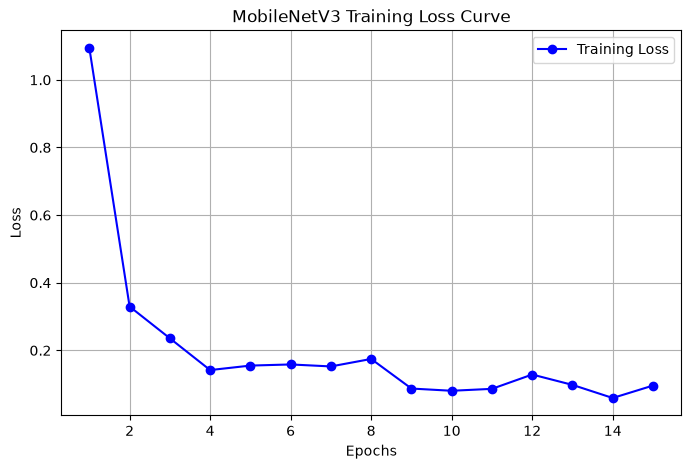

MobileNet loss graph saved successfully at: ./models/mobilenet_training_loss.png


In [4]:
# Cell 4: Execute MobileNetV3 Custom PyTorch Pipeline
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

project_base = "."

class TextileDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        self.img_paths = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
            self.img_paths.extend(glob.glob(os.path.join(img_dir, ext)))

        self.labels = []
        for img_path in self.img_paths:
            label_path = img_path.replace('images', 'labels')
            label_path = os.path.splitext(label_path)[0] + '.txt'

            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    first_line = f.readline().strip()
                    if first_line:
                        class_id = int(first_line.split()[0])
                        self.labels.append(class_id)
                    else:
                        self.labels.append(0)
            else:
                self.labels.append(0)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dir = os.path.join(project_base, "dataset/split_textiles/images/train")
val_dir = os.path.join(project_base, "dataset/split_textiles/images/val")

train_dataset = TextileDataset(train_dir, transform=data_transforms)
val_dataset = TextileDataset(val_dir, transform=data_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

all_labels = train_dataset.labels + val_dataset.labels
num_classes = len(set(all_labels)) if len(all_labels) > 0 else 1

print(f"Dataset Loaded. Training: {len(train_dataset)}, Validation: {len(val_dataset)}")

mobilenet_model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
num_ftrs = mobilenet_model.classifier[3].in_features
mobilenet_model.classifier[3] = nn.Linear(num_ftrs, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mobilenet_model = mobilenet_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet_model.parameters(), lr=0.001)

print("Starting MobileNet training...")
num_epochs = 15
loss_history = []

for epoch in range(num_epochs):
    mobilenet_model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = mobilenet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset) if len(train_dataset) > 0 else 0
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Training Loss: {epoch_loss:.4f}")

model_folder = os.path.join(project_base, "models")
os.makedirs(model_folder, exist_ok=True)

model_save_path = os.path.join(model_folder, "mobilenet_textiles.pth")
torch.save(mobilenet_model.state_dict(), model_save_path)
print(f"Model saved successfully at: {model_save_path}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), loss_history, marker='o', color='b', label='Training Loss')
plt.title('MobileNetV3 Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
graph_save_path = os.path.join(model_folder, "mobilenet_training_loss.png")
plt.savefig(graph_save_path)
plt.show()
print(f"MobileNet loss graph saved successfully at: {graph_save_path}")

In [ ]:
# Cell 5: Simultaneous Weights Loading and Unified Evaluation
import os
import yaml
import time
import gradio as gr
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image

project_base = "."

yaml_path = os.path.join(project_base, "dataset/data.yaml")
if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        yaml_data = yaml.safe_load(f)
    class_names = yaml_data.get('names', {})
else:
    class_names = {0: "Default Textile"}

num_classes = len(class_names)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 1. Initialize and Load MobileNetV3 Engine
mobilenet_deployed = models.mobilenet_v3_large(weights=None)
mobilenet_deployed.classifier[3] = nn.Linear(mobilenet_deployed.classifier[3].in_features, num_classes)
mobilenet_weight_path = os.path.join(project_base, "models/mobilenet_textiles.pth")
if os.path.exists(mobilenet_weight_path):
    mobilenet_deployed.load_state_dict(torch.load(mobilenet_weight_path, map_location=device))
    mobilenet_deployed = mobilenet_deployed.to(device).eval()
    print("MobileNetV3 model loaded successfully from disk.")

# 2. Initialize and Load ResNet50 Engine
resnet_deployed = models.resnet50(weights=None)
resnet_deployed.fc = nn.Linear(resnet_deployed.fc.in_features, num_classes)
resnet_weight_path = os.path.join(project_base, "models/resnet50_textiles.pth")
if os.path.exists(resnet_weight_path):
    resnet_deployed.load_state_dict(torch.load(resnet_weight_path, map_location=device))
    resnet_deployed = resnet_deployed.to(device).eval()
    print("ResNet50 model loaded successfully from disk.")

# 3. Initialize and Load EfficientNet-B0 Engine
efficientnet_deployed = models.efficientnet_b0(weights=None)
efficientnet_deployed.classifier[1] = nn.Linear(efficientnet_deployed.classifier[1].in_features, num_classes)
efficientnet_weight_path = os.path.join(project_base, "models/efficientnet_textiles.pth")
if os.path.exists(efficientnet_weight_path):
    efficientnet_deployed.load_state_dict(torch.load(efficientnet_weight_path, map_location=device))
    efficientnet_deployed = efficientnet_deployed.to(device).eval()
    print("EfficientNet-B0 model loaded successfully from disk.")

def evaluate_similarity(input_image, model_choice):
    if input_image is None:
        return None, "Please upload an image to start verification."

    pil_img = Image.fromarray(input_image).convert("RGB")
    input_tensor = inference_transforms(pil_img).unsqueeze(0).to(device)
    
    if "MobileNetV3" in model_choice:
        model = mobilenet_deployed
        model_label = "MobileNetV3 (Lightweight)"
    elif "ResNet50" in model_choice:
        model = resnet_deployed
        model_label = "ResNet50 (Standard Depth)"
    else:
        model = efficientnet_deployed
        model_label = "EfficientNet-B0 (Compound Scaling)"

    start_time = time.time()
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
    inference_speed = (time.time() - start_time) * 1000

    best_prob, best_class = torch.max(probabilities, 0)
    score_percentage = best_prob.item() * 100
    detected_motif = class_names.get(best_class.item(), f"Class {best_class.item()}")

    if score_percentage >= 95.00:
        decision_text = (
            f"Active Architecture: {model_label}\n"
            f"Inference Latency: {inference_speed:.2f} ms\n\n"
            f"MATCH SCORE: {score_percentage:.2f}%\n"
            f"Identified Motif Pattern: {detected_motif}\n\n"
            f"CRITICAL WARNING: This specific design pattern already exists inside the database repository.\n"
            f"Action Required: You must reject this layout, redraw the sketch, and submit a new pattern variation."
        )
    else:
        decision_text = (
            f"Active Architecture: {model_label}\n"
            f"Inference Latency: {inference_speed:.2f} ms\n\n"
            f"MATCH SCORE: {score_percentage:.2f}%\n"
            f"Closest Structural Class: {detected_motif}\n\n"
            f"STATUS: CLEAR / SAFE TO USE\n"
            f"Verification Result: No severe similarity conflicts detected. You can safely proceed with this garment creation sequence."
        )

    return input_image, decision_text

demo = gr.Interface(
    fn=evaluate_similarity,
    inputs=[
        gr.Image(label="Upload Clothing Pattern Sketch or Fabric Image"),
        gr.Radio(
            choices=[
                "MobileNetV3 (Fast & Efficient)", 
                "ResNet50 (Deep Feature Extraction)", 
                "EfficientNet-B0 (Optimized Balance)"
            ],
            value="MobileNetV3 (Fast & Efficient)",
            label="Select Evaluation Model Architecture"
        )
    ],
    outputs=[
        gr.Image(label="Processed Design File View"),
        gr.Textbox(label="Archive Similarity Search Results & Production Instruction", lines=10)
    ],
    title="Garment Pattern Originality Verification System",
    description="Upload new clothing production sketches to calculate motif duplicate thresholds against database records before running the sewing sequence."
)

demo.launch(share=False)

/home/zen/VSCodeWSL/AI_Jupyter/AI_Project_Semester6/ClothesDefect/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MobileNetV3 model loaded successfully from disk.
ResNet50 model loaded successfully from disk.
EfficientNet-B0 model loaded successfully from disk.
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


/home/zen/VSCodeWSL/AI_Jupyter/AI_Project_Semester6/ClothesDefect/.venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/home/zen/VSCodeWSL/AI_Jupyter/AI_Project_Semester6/ClothesDefect/.venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/home/zen/VSCodeWSL/AI_Jupyter/AI_Project_Semester6/ClothesDefect/.venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/home/zen/VSCodeWSL/AI_Jupyter/AI_Project_Semester6/ClothesDefect/.venv/lib/python3.12/s